In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time, os
from PIL import Image

In [7]:
#Parameters

start = time.time()

#Value of gravitational acceleration
g =  1

#Length and mass of the top rod
l1 = 0.3
m1 = 1
#Length and mass of the second rod
l2 = 0.3
m2 = 20

In [8]:

    
    def RK4(t1, theta1_0, theta2_0, v1_0, v2_0, h):
    
        #Initialise the arrays to be used
        # t is an array containing each of the timepoints that we will step forward to
        t = np.arange(0,t1+h,h)
        # n is the number of timesteps in t
        n = np.shape(t)[0]
        # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
        theta1 = np.zeros(n)
        theta2 = np.zeros(n)
        #same for velocities
        v1 = np.zeros(n)
        v2 = np.zeros(n)
        
        E = np.zeros(n)
        K = np.zeros(n)
        P = np.zeros(n)
        P2 = np.zeros(n)
        M = m1+m2
    
        #Set the initial value of x and v
        theta1[0] = theta1_0
        v1[0] = v1_0
        theta2[0] = theta2_0
        v2[0] = v2_0
        
        #calculations for getting total energy 
        M = m1 + m2
    
        #define F(theta) for coupled equation 1
        def F1(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
        #Define G(v) for coupled equation 1
        def G1(v1):
        
            return v1
    
        #define F(theta) for coupled equation 2
        def F2(theta1, theta2, v1, v2):
        
            thetaDiff = theta1-theta2
            a = m1 + m2*(np.sin(thetaDiff))**2
        
            return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
        #Define G(v) for coupled equation 2
        def G2(v2):
        
            return v2
    
    
        #Loop over the time values and calculate the derivatives
        for i in range(1,n): 
            # Calculate the Runge - Kutta intermediate values for both formulas
            f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
            f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
            f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
            g1 = h * G1(v1[i-1])
            g2 = h * G1(v1[i-1]+g1/2)
            g3 = h * G1(v1[i-1]+g2/2)
            g4 = h * G1(v1[i-1]+g3)
        
            e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
            e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
            e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
            e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
            j1 = h * G2(v2[i-1])
            j2 = h * G2(v2[i-1]+j1/2)
            j3 = h * G2(v2[i-1]+j2/2)
            j4 = h * G2(v2[i-1]+j3)
        
            theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
            v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
            theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
            v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
            
            
            #computing the kinetic, potential and total energy at each step.
            # I have double checked and triple checked, and checked again that these equations match 
            # those online, 
            # I have played around with making g -9.8, vs +9.8, 
            # I just can't figure out why the total enenrgy is negative and why potential energy dominates kinetic so much.
            # Perhaps it's OK and I'm overthinking. 
            # added 246.4 and 3.6 to the potential to deal with the weird offset, idk don't ask.
            K[i] = 0.5 *(m1+m2) *l1**2 *v1[i]**2 + 0.5 *m2 *l2**2 *v2[i]**2 + m2 *l1 *l2 *v1[i] *v2[i] *np.cos(theta1[i]-theta2[i])
            P[i] = -(m1+m2) *g *l1 *np.cos(theta1[i]) - m2 *g *l2 *np.cos(theta2[i])
            P2[i] = m1*g*l1*(1-np.cos(theta1[i])) + m2*g*l2*(1-np.cos(theta2[i]))
            # + 246.39564753573094 + 3.620848701847998
            
            
            #the if statements below include the periodicity of the pendulum
            #so if one the pendulums goes round in a full loop, the value of theta 
            #is reset to zero
            if theta1[i] >= 2*np.pi:
                theta1[i] -= 2*np.pi
            
            if theta1[i] <= -2*np.pi:
                theta1[i] += 2*np.pi
            
            if theta2[i] >= 2*np.pi:
                theta2[i] -= 2*np.pi
              
            if theta2[i] <= -2*np.pi:
                theta2[i] += 2*np.pi
            
        # P += np.max(K)
        # P[1:] -= np.max(P[1]) 
       
        # + np.abs(np.max(P[1:])-np.min(P[1:]))
        # P[1:] += np.abs(P[1])
        # P[1:] += np.abs(np.max(P[1:])-np.min(P[1:]))
        E = K + P
        return(t,theta1,theta2,v1,v2,E,P,P2,K,h)

In [4]:
#Run the algorithm and print the energy at different time points
start_time = time.time()

t, theta1, theta2, v1, v2, E, P, P2, K, h = RK4(t1=20, theta1_0=0.60, theta2_0=0.60, v1_0=0, v2_0=0, h=0.00001)

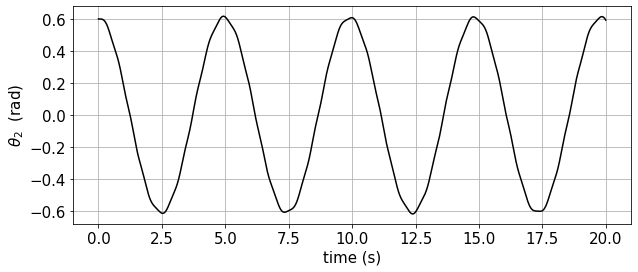

In [10]:
#Cell to plot the solution


#same data with two axis for energy and position 
fig, ax1 = plt.subplots(figsize=(10,4))

# plt.figure(figsize=[10,7])
# fig.xticks(size=12)
ax1.set_xlabel('time (s)', fontsize=15)
ax1.set_ylabel('$θ_2$  (rad)', size=15)
ax1.plot(t, theta2,label='Outer Arm Angle', color='black')
# ax1.plot(t[1:2], theta1[1:2], label='Mathematica solution')
#plt.legend(bbox_to_anchor=(1.007, 1), fontsize=1)
# ax1.xticks(size=20)
# plt.axhline(y=0, linestyle='--')
plt.xticks(size=15)
plt.yticks(size=15)
ax1.grid(True)
# ax2=ax1.twinx()
# ax2.plot(t[1:], E[1:], color='r', label='Energy')
# ax2.legend(fontsize=18)
# ax2.set_ylabel('Energy [J]', size=20)
# ax2.tick_params(labelsize=15)
# ax2 = ax1.twinx()
# ax2.set_ylabel('Energy (J)', size=20)
# plt.yticks(size=15)
# ax2.plot(t[1:], E[1:], color='r')
# plt.title('Double Pendulum solution for $\Theta_1$', size=22)
# plt.savefig("double with chaos BC's 3 .png")
plt.show()

In [12]:
start_time = time.time()

t2, theta12, theta22, v12, v22, E2, P2, P22, K2, h2 = RK4(t1=10, theta1_0=np.pi/6, theta2_0=-np.pi, v1_0=0, v2_0=0, h=0.0005)

print("--- %s seconds ---" % (time.time() - start_time))

# for i in range(len(E)):
#     if np.abs(t2[i]-0.001)<=0+h2:
#         print ("RK4 energy at t={0:.2f} is {1:.5f}".format(t2[i], E2[i]))
            
#     if  np.abs(t2[i]-2)<= 0.0005:
#         print ("RK4 energy at t={0:.2f} is {1:.5f}".format(t2[i], E2[i]))
            
#     if  np.abs(t2[i]-10)<= 0.0005:
#          print ("RK4 energy at t={0:.2f} is {1:.5f}".format(t2[i], E2[i]))
            
#     if  np.abs(t2[i]-40)<= 0.005:
#          print ("RK4 energy at t={0:.2f} is {1:.5f}".format(t2[i], E2[i]))
print(t[-1])
print(E2[-1])
print('e rel: {0}'.format(np.abs(E2[1]-E2[-1])/E2[1]*100))

/tmp/ipykernel_712639/1867451970.py:36: RuntimeWarning: overflow encountered in scalar power
  return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
/tmp/ipykernel_712639/1867451970.py:36: RuntimeWarning: invalid value encountered in scalar multiply
  return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
/tmp/ipykernel_712639/1867451970.py:49: RuntimeWarning: overflow encountered in scalar power
  return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
/tmp/ipykernel_712639/1867451970.py:49: RuntimeWarning: invalid value encountered in scalar multiply
  return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)


--- 2.108181953430176 seconds ---
10.0
nan
e rel: nan


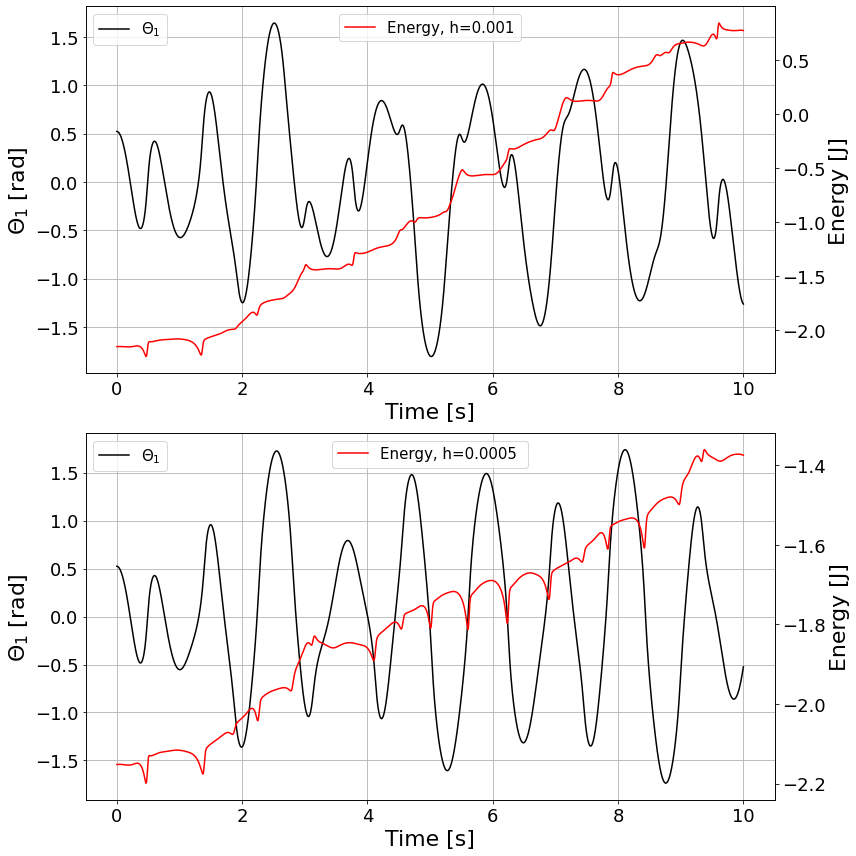

In [90]:
fig, ax1 = plt.subplots(2,1,figsize=(12,12))

ax1[0].plot(t[1:], theta1[1:], color='black', label='$\Theta_1$')
ax1[0].set_xlabel('Time [s]', size=22)
ax1[0].set_ylabel('$\Theta_1$ [rad]',size=22)
# ax1[0].set_xticks(ticks=np.arange(0,12,2), labelsize='large', fontsize=25)
ax1[0].tick_params(labelsize=18)
ax2 = ax1[0].twinx()
ax2.plot(t[1:],E[1:], color='red', label='Energy, h=0.001')
ax2.set_ylabel('Energy [J]', size=22)
ax2.tick_params(labelsize=18)
leg = ax1[0].legend(loc="upper left", fontsize=15)
leg = ax2.legend(loc="upper center", fontsize=15)
ax1[0].grid()

ax1[1].plot(t2[1:], theta12[1:], color='black', label='$\Theta_1$')
ax1[1].set_xlabel('Time [s]', size=22)
ax1[1].set_ylabel('$\Theta_1$ [rad]',size=22)
ax1[1].tick_params(labelsize=18)
ax3 = ax1[1].twinx()
ax3.plot(t2[1:],E2[1:], color='red', label='Energy, h=0.0005 ')
ax3.set_ylabel('Energy [J]', size=22)
ax3.tick_params(labelsize=18)
leg = ax1[1].legend(loc="upper left", fontsize=15)
leg = ax3.legend(loc="upper center", fontsize=15)
ax1[1].grid()

plt.tight_layout()
plt.savefig("double pen chaos h and h half.pdf")
plt.show()

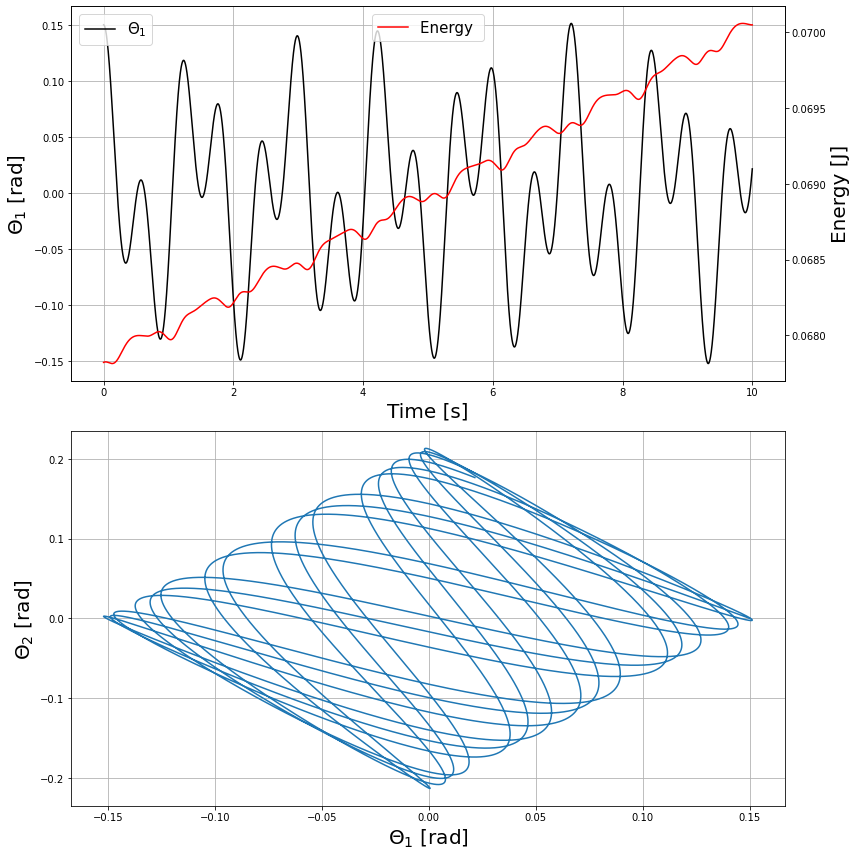

In [12]:
# plt.figure(figsize=[13,7])
# plt.plot(t,theta1)
# # plt.plot(t,theta2)
# plt.plot(t[1:], E[1:], label='total energy')
# plt.title('Theta 1 against time', weight='bold')
# plt.xlabel('Time')
# plt.ylabel('Theta 1 (rads)')
# # plt.legend()
# plt.show()


fig, ax1 = plt.subplots(2,1,figsize=(12,12))
# plt.xticks(size=15)
# plt.yticks(size=15)
ax1[0].set_xlabel('Time [s]', size=20)
ax1[0].set_ylabel('$\Theta_1$ [rad]',size=20)
# ax1[0].set_xticks(size=15)
# ax1[0].set_yticks(size=15)
ax1[0].plot(t[1:], theta1[1:], color='black', label='$\Theta_1$')
# plt.xticks( [4, 14, 24],  [5, 15, 25] )
# ax1[0].plot(t[1:], E[1:], color='r', label='Total Energy')

ax2 = ax1[0].twinx()
ax2.set_ylabel('Energy [J]', size=20)
# ax2.plot(t[1:], P[1:], color='r', label='Potential')
ax2.plot(t[1:],E[1:], color='red', label='Energy ')
leg = ax1[0].legend(loc="upper left", fontsize=15)
leg = ax2.legend(loc="upper center", fontsize=15)
ax1[0].grid()
# ax1[1].axis('off')
# plt.yticks([])
# ax3 = ax1[1].twinx()
ax1[1].plot(theta1, theta2)
ax1[1].set_xlabel('$\Theta_1$ [rad]', size=20)
ax1[1].set_ylabel('$\Theta_2 $ [rad]', size=20)
# ax3.plot(theta1, theta2)
# ax3.set_ylabel('$\Theta_2$', size=20)
ax1[1].grid()
plt.tight_layout()
plt.savefig("Theta1, energy, LF, double, simple bc, h-0.001.pdf")
plt.show()

In [140]:
#This cell will print out the energies measured at every single step
# Just comment it out if you don't need to see them, or leave it in if you are investigating. 
for i in range(5):
    print('Total: {0:.3f}, potential: {1}, kinetic: {2:.8f}'.format(E[i], P[i], K[i]))
print(K[0], K[1])

Total: 0.000, potential: 0.0, kinetic: 0.00000000
Total: 0.110, potential: 0.1101951641092569, kinetic: 0.00000056
Total: 0.110, potential: 0.11019402390567601, kinetic: 0.00000224
Total: 0.110, potential: 0.11019174360728945, kinetic: 0.00000505
Total: 0.110, potential: 0.1101883234673311, kinetic: 0.00000897
0.0 5.607193083278187e-07


#### In the hidden cells below are some plots desgined to plot the potential, kinetic and total energy.
#### They can be useful to see if the energy is behaving as you expect.
#### Something I find helpful is to model the double pendulum to be as close to a simple pendulum as possible, i.e 
#### make mass 2 and length 2 much smaller than mass 1 and length 1, and see if the energy is behaving as you expect.
#### Also comparing these plots with the GIF created can be helpful. However, remember that in the cell for the GIF at the bottom of 
#### this notebook, you have to redefine the initial conditions and parameters to be the same as have made the plots in this part
#### of the notebook.

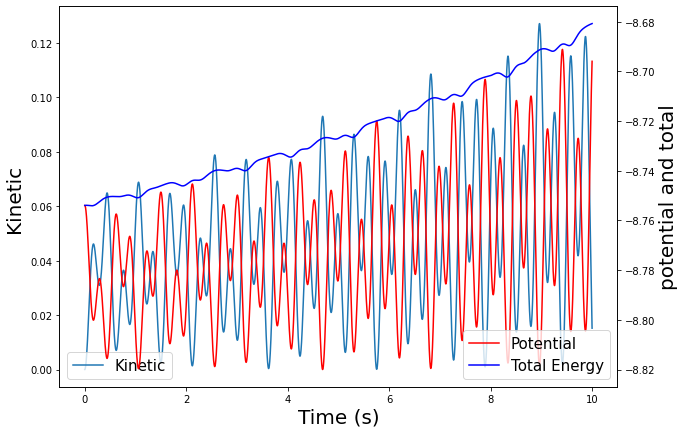

In [58]:
# plt.figure(figsize=[10,7])
# plt.plot(t[1:], P[1:], label='potential')
# plt.plot(t[1:],K[1:], label='kinetic')
# plt.plot(t[1:], E[1:], label='total')
# plt.legend()


#same data with two axis for energy and position 
fig, ax1 = plt.subplots(figsize=(10,7))

# plt.figure(figsize=[10,7])

ax1.set_xlabel('Time (s)', size=20)
ax1.set_ylabel('Kinetic ',size=20)
ax1.plot(t[1:], K[1:], label='Kinetic')

ax2 = ax1.twinx()
ax2.set_ylabel('potential and total', size=20)
ax2.plot(t[1:], P[1:], color='r', label='Potential')
ax2.plot(t[1:],E[1:], color='b', label='Total Energy')
leg = ax1.legend(loc="lower left", fontsize=15)
leg = ax2.legend(loc="lower right", fontsize=15)
plt.show()

plt.figure(figsize=[10,7])
plt.plot(t,theta1)
plt.plot(t[1:], E[1:], label='Energy')
plt.title('Theta 1 against time', weight='bold')
plt.xlabel('Time')
plt.ylabel('Theta 1 (rads)')
plt.legend()
plt.show()

In [19]:
#Code to create a GIF of the double pendulum.
#Note that you have to redefine the intial conditions and parameters below

start_time = time.time()

#RK4 function is called here, define initial conditions and parameters.
t, theta1, theta2, v1, v2, E, P, K, h = RK4(t1=10, theta1_0=np.pi/3, theta2_0=-np.pi, v1_0=0, v2_0=0, h=0.00001)
                                              
x1 = l1*np.sin(theta1)
y1 = -l1*np.cos(theta1)

x2 = x1 + l2*np.sin(theta2)
y2 = y1 - l2*np.cos(theta2)
# print(theta1)
frames = []
t_last_frame=0
for i in range(len(x1)):
    if np.abs((t[i] - t_last_frame) > (0.02)):
        t_last_frame = t[i]
        fig=plt.figure(figsize=[10,7])
        plt.plot((0, x1[i]), (0, y1[i]))
        plt.plot((x1[i], x2[i]), (y1[i], y2[i]))
        plt.xlim(-1, 1)
        plt.ylim(-1, 0.2)
    
        canvas = plt.get_current_fig_manager().canvas
        canvas.draw()
        im = Image.frombytes('RGB', canvas.get_width_height(), canvas.tostring_rgb())
        frames.append(im)
            
        plt.close(fig)
    #plt.show(fig)
timestamp=time.time()
frames[0].save("rk4_{0} chaotic bc.gif".format(timestamp), format='GIF', append_images=frames[1:], save_all=True, duration=50, loop=0)

print("--- %s seconds ---" % (time.time() - start_time))

ValueError: too many values to unpack (expected 9)